# 02 Screening Workflow and Sample Construction

This notebook generates the single-column, equal-width systematic-review flowchart Fig. 2 using the raw-directory accounting basis:

- The top contains only one main `Search design` box: it lists 37 search terms and preserves the summary of 13 years from 2014-2026, 2 query fields, and 37 × 13 × 2 = 962 query executions.
- The left side uses three vertical stage blocks for searching / deduplication / corpus construction.
- The six boxes below share the same x coordinate, left/right boundaries, and width as the top main box, and are continuously connected by vertical straight arrows.
- Standard main-flow boxes use black borders and white fills; only the two data-accounting boxes use light grey fills.
- Place `Non-unique query observations collapsed` below `Records identified through systematic query execution`, showing N = 5,198 and 34,098 - 28,900.
- Place `Records not retained in final corpus` below `Unique raw projects after project-level deduplication`, showing N = 19,678, 68.1%, and reason-coded history unavailable.
- The final retained projects are N = 9,222, or 31.9% of unique raw projects, summarized in the final master-corpus box.
- By default, this task only overwrites the four Fig. 2 formats in place and does not write the screening-flow table or method log.


In [1]:
# Import basic libraries and set project paths and Fig. 2 output paths.
from pathlib import Path
import textwrap
from datetime import datetime

import pandas as pd
import matplotlib as mpl
from matplotlib import font_manager
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, FancyBboxPatch

# Use Times New Roman and preserve editable SVG/PDF text.
FONT_FILES = [
    Path("/System/Library/Fonts/Supplemental/Times New Roman.ttf"),
    Path("/System/Library/Fonts/Supplemental/Times New Roman Bold.ttf"),
    Path("/System/Library/Fonts/Supplemental/Times New Roman Italic.ttf"),
    Path("/System/Library/Fonts/Supplemental/Times New Roman Bold Italic.ttf"),
]
for font_path in FONT_FILES:
    if font_path.exists():
        font_manager.fontManager.addfont(str(font_path))

regular_times_path = FONT_FILES[0]
if not regular_times_path.exists():
    raise RuntimeError("Times New Roman font file is required for Fig2 rendering.")
FIGURE_FONT = font_manager.FontProperties(fname=str(regular_times_path)).get_name()
font_manager.findfont(FIGURE_FONT, fallback_to_default=False)

TEXT_FONT_FAMILIES = [FIGURE_FONT, "Times New Roman", "Times", "DejaVu Serif", "serif"]

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": TEXT_FONT_FAMILIES,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "font.size": 10,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 0.8,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

# Auto-detect the project root, supporting execution from either the project root or the code/ directory.
HERE = Path.cwd().resolve()
if (HERE / "data").exists():
    PROJECT_ROOT = HERE
elif (HERE.parent / "data").exists():
    PROJECT_ROOT = HERE.parent
else:
    raise FileNotFoundError("Could not locate the project root: data/ was not found in the current directory or its parent.")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
FIGURE_DIR = PROJECT_ROOT / "output" / "figures"
TABLE_DIR = PROJECT_ROOT / "output" / "tables"
LOG_DIR = PROJECT_ROOT / "output" / "logs"

KEYWORD_TERMS_PATH = DATA_DIR / "NSFC正式增量采集_37个关键词.csv"
RAW_COLLECTION_PATH = RAW_DIR / "NSFC正式增量采集_原始抓取结果.csv"
RAW_QUERY_LIST_PATH = RAW_DIR / "NSFC正式增量采集_查询清单.csv"
RAW_QUERY_PROGRESS_PATH = RAW_DIR / "NSFC正式增量采集_查询进度表.csv"
MASTER_PATH = DATA_DIR / "NSFC正式增量采集_2014-2026_去重筛选最终结果.csv"

FLOW_TABLE_PATH = TABLE_DIR / "02_screening_flow.csv"
METHOD_LOG_PATH = LOG_DIR / "02_screening_methods.md"
FIGURE_BASE = FIGURE_DIR / "Fig2_screening_workflow"

# This run may overwrite only the four Fig. 2 formats; table and log export are disabled by default.
EXPORT_FIG2_OUTPUTS = True
EXPORT_TABLE_AND_LOG_OUTPUTS = False

PROJECT_ROOT


PosixPath('/Volumes/ZHITAI2T/202607综述BAE')

In [2]:
# Read the specified raw/final data sources and compute the n values needed for the enhanced transparent Fig. 2.
def read_csv_text(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing required data file: {path}")
    return pd.read_csv(path, dtype=str, keep_default_na=False, low_memory=False)


def clean_series(df: pd.DataFrame, col: str) -> pd.Series:
    return df[col].fillna("").astype(str).str.strip()


def require_columns(df: pd.DataFrame, required_cols: list[str], label: str) -> None:
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise KeyError(f"{label} is missing required columns: {missing_cols}")


keyword_terms_df = read_csv_text(KEYWORD_TERMS_PATH)
raw_df = read_csv_text(RAW_COLLECTION_PATH)
query_list_df = read_csv_text(RAW_QUERY_LIST_PATH)
query_progress_df = read_csv_text(RAW_QUERY_PROGRESS_PATH)
master_df = read_csv_text(MASTER_PATH)

require_columns(keyword_terms_df, ["term"], "keyword terms")
require_columns(raw_df, ["detail_id", "approval_no", "query_count"], "raw collection")
require_columns(query_list_df, ["query_id", "query_keyword", "search_field", "year_value"], "raw query list")
require_columns(query_progress_df, ["query_id", "query_keyword", "rows_seen", "total_records", "new_projects", "status"], "raw query progress")
require_columns(master_df, ["approval_no", "detail_id"], "final master")

search_terms_from_keyword_file = clean_series(keyword_terms_df, "term").loc[lambda s: s.ne("")].drop_duplicates().tolist()
search_terms_from_query_list = clean_series(query_list_df, "query_keyword").loc[lambda s: s.ne("")].drop_duplicates().tolist()
search_terms_from_progress = clean_series(query_progress_df, "query_keyword").loc[lambda s: s.ne("")].drop_duplicates().tolist()
search_terms = search_terms_from_query_list

# English labels reuse KEYWORD_EN_LABELS from the Fig. 6 temporal topic heatmap.
FIG6_KEYWORD_EN_LABELS = {
    "遥感": "Remote sensing",
    "大数据": "Big data",
    "GIS": "GIS",
    "高分": "High-resolution imagery",
    "多源数据": "Multisource data",
    "三维": "3D",
    "机器学习": "Machine learning",
    "深度学习": "Deep learning",
    "地理信息": "Geoinformation",
    "轨迹": "Trajectory",
    "街景": "Street view",
    "人工智能": "Artificial intelligence",
    "POI": "POI",
    "夜间灯光": "Nighttime lights",
    "手机信令": "Mobile signaling",
    "LiDAR": "LiDAR",
    "LBS": "LBS",
    "规划": "Planning",
    "城市群": "Urban agglomeration",
    "土地利用": "Land use",
    "建筑": "Buildings",
    "绿地": "Green space",
    "街道": "Street",
    "建成环境": "Built environment",
    "街区": "Block",
    "海绵": "Sponge city",
    "城市形态": "Urban morphology",
    "气候": "Climate",
    "生态环境": "Ecological environment",
    "碳": "Carbon",
    "热岛": "Heat island",
    "韧性": "Resilience",
    "热环境": "Thermal environment",
    "暴露": "Exposure",
    "洪涝": "Flooding",
    "能源": "Energy",
    "空气污染": "Air pollution",
}
search_terms_english = [FIG6_KEYWORD_EN_LABELS[term] for term in search_terms]

query_executions_n = int(len(query_list_df))
query_progress_rows_n = int(len(query_progress_df))
query_keyword_n = int(clean_series(query_list_df, "query_keyword").nunique())
query_year_n = int(clean_series(query_list_df, "year_value").nunique())
query_field_n = int(clean_series(query_list_df, "search_field").nunique())
query_year_min = int(pd.to_numeric(clean_series(query_list_df, "year_value"), errors="coerce").min())
query_year_max = int(pd.to_numeric(clean_series(query_list_df, "year_value"), errors="coerce").max())
query_rows_seen_n = int(pd.to_numeric(clean_series(query_progress_df, "rows_seen"), errors="coerce").fillna(0).sum())
query_total_records_n = int(pd.to_numeric(clean_series(query_progress_df, "total_records"), errors="coerce").fillna(0).sum())
query_new_projects_sum_n = int(pd.to_numeric(clean_series(query_progress_df, "new_projects"), errors="coerce").fillna(0).sum())
raw_query_count_sum_n = int(pd.to_numeric(clean_series(raw_df, "query_count"), errors="coerce").fillna(0).sum())

raw_retrieved_n = int(len(raw_df))
raw_approval_no_unique_n = int(clean_series(raw_df, "approval_no").loc[lambda s: s.ne("")].nunique())
raw_detail_id_unique_n = int(clean_series(raw_df, "detail_id").loc[lambda s: s.ne("")].nunique())
raw_unique_after_merge_n = raw_retrieved_n

final_corpus_n = int(len(master_df))
raw_keys = set(zip(clean_series(raw_df, "approval_no"), clean_series(raw_df, "detail_id")))
raw_keys.discard(("", ""))
final_keys = set(zip(clean_series(master_df, "approval_no"), clean_series(master_df, "detail_id")))
final_keys.discard(("", ""))
final_traced_to_raw_n = int(len(final_keys & raw_keys))
final_only_n = int(len(final_keys - raw_keys))
collapsed_query_observations_n = int(query_rows_seen_n - raw_unique_after_merge_n)
not_carried_forward_n = int(raw_unique_after_merge_n - final_corpus_n)
not_carried_by_key_n = int(len(raw_keys - final_keys))
final_retention_pct = final_corpus_n / raw_unique_after_merge_n
not_retained_pct = not_carried_forward_n / raw_unique_after_merge_n
reason_coded_exclusion_history_available = False
workflow_mode = "single_column_systematic_review_flowchart"

assert len(search_terms_from_keyword_file) == 37
assert search_terms_from_query_list == search_terms_from_keyword_file
assert search_terms_from_progress == search_terms_from_keyword_file
assert set(search_terms) == set(FIG6_KEYWORD_EN_LABELS)
assert len(search_terms_english) == 37 and len(set(search_terms_english)) == 37
assert query_executions_n == query_progress_rows_n == 962
assert query_keyword_n == len(search_terms) == 37 and query_year_n == 13 and query_field_n == 2
assert query_year_min == 2014 and query_year_max == 2026
assert query_rows_seen_n == query_total_records_n == raw_query_count_sum_n == 34098
assert query_new_projects_sum_n == raw_retrieved_n == 28900
assert raw_retrieved_n == raw_approval_no_unique_n == raw_detail_id_unique_n == 28900
assert collapsed_query_observations_n == 5198
assert final_corpus_n == 9222
assert final_traced_to_raw_n == final_corpus_n and final_only_n == 0
assert not_carried_forward_n == not_carried_by_key_n == 19678
assert round(final_retention_pct * 100, 1) == 31.9
assert round(not_retained_pct * 100, 1) == 68.1
assert not reason_coded_exclusion_history_available

print(f"Search terms validated: {len(search_terms)} terms from {KEYWORD_TERMS_PATH.name}; raw query list and progress table match.")
print("Chinese search terms: " + "; ".join(search_terms))
print("English display terms: " + "; ".join(search_terms_english))
print(f"Search design: {query_keyword_n} search terms; {query_year_n} years ({query_year_min}-{query_year_max}); {query_field_n} query fields; N = {query_executions_n:,} executions")
print(f"Query hits / rows seen: {query_rows_seen_n:,}")
print(f"Collapsed non-unique query observations: {collapsed_query_observations_n:,}")
print(f"Unique raw projects after project-level deduplication: {raw_unique_after_merge_n:,}")
print(f"Final master corpus: {final_corpus_n:,} ({final_retention_pct:.1%} of unique raw projects)")
print(f"Not retained in final corpus: {not_carried_forward_n:,} ({not_retained_pct:.1%})")


Search terms validated: 37 terms from NSFC正式增量采集_37个关键词.csv; raw query list and progress table match.
Chinese search terms: 规划; 遥感; 城市群; 大数据; 气候; GIS; 土地利用; 建筑; 高分; 多源数据; 生态环境; 三维; 机器学习; 碳; 绿地; 深度学习; 热岛; 韧性; 热环境; 暴露; 地理信息; 洪涝; 街道; 建成环境; 能源; 轨迹; 街景; 街区; 人工智能; 海绵; 城市形态; POI; 夜间灯光; 空气污染; 手机信令; LiDAR; LBS
English display terms: Planning; Remote sensing; Urban agglomeration; Big data; Climate; GIS; Land use; Buildings; High-resolution imagery; Multisource data; Ecological environment; 3D; Machine learning; Carbon; Green space; Deep learning; Heat island; Resilience; Thermal environment; Exposure; Geoinformation; Flooding; Street; Built environment; Energy; Trajectory; Street view; Block; Artificial intelligence; Sponge city; Urban morphology; POI; Nighttime lights; Air pollution; Mobile signaling; LiDAR; LBS
Search design: 37 search terms; 13 years (2014-2026); 2 query fields; N = 962 executions
Query hits / rows seen: 34,098
Collapsed non-unique query observations: 5,198
Unique raw project

In [3]:
# Summarize Fig. 2 data sources. This table is used only for in-notebook checks and is not written to output/tables by default.
fig2_source_summary = pd.DataFrame([
    {
        "figure_element": "Search design",
        "n": query_executions_n,
        "source": f"{KEYWORD_TERMS_PATH.name}; {RAW_QUERY_LIST_PATH.name}",
        "calculation": f"{query_keyword_n} search terms x {query_year_n} years ({query_year_min}-{query_year_max}) x {query_field_n} query fields",
    },
    {
        "figure_element": "Records identified through systematic query execution",
        "n": query_rows_seen_n,
        "source": RAW_QUERY_PROGRESS_PATH.name,
        "calculation": "sum(rows_seen); cross-checked against raw query_count sum",
    },
    {
        "figure_element": "Non-unique query observations collapsed",
        "n": collapsed_query_observations_n,
        "source": f"{RAW_QUERY_PROGRESS_PATH.name}; {RAW_COLLECTION_PATH.name}",
        "calculation": "34,098 query hits / rows seen - 28,900 unique raw projects; duplicate observations across query executions",
    },
    {
        "figure_element": "Unique raw projects after project-level deduplication",
        "n": raw_unique_after_merge_n,
        "source": RAW_COLLECTION_PATH.name,
        "calculation": "raw rows after approval_no/detail_id merge",
    },
    {
        "figure_element": "Records not retained in final corpus",
        "n": not_carried_forward_n,
        "source": f"{RAW_COLLECTION_PATH.name}; {MASTER_PATH.name}",
        "calculation": "aggregate records not retained in final master corpus; reason-coded history unavailable",
    },
    {
        "figure_element": "Projects retained in final master corpus",
        "n": final_corpus_n,
        "source": MASTER_PATH.name,
        "calculation": "rows in current final master file; 31.9% of unique raw projects",
    },
    {
        "figure_element": "Final master corpus included for analysis",
        "n": final_corpus_n,
        "source": MASTER_PATH.name,
        "calculation": "final analysis corpus equals the retained final master corpus",
    },
])

workflow_notes = [
    "Fig2 is a single-column systematic review data-accounting flowchart.",
    "The Search design header and all six downstream boxes share the same left/right boundaries and width.",
    "Three left-side stage bars label searching, deduplication accounting, and corpus construction.",
    "Non-unique query observations are placed immediately below records identified.",
    "Records not retained in final corpus are placed immediately below unique raw projects.",
    "Reason-coded exclusion history was unavailable; counts describe data accounting, not audited screening reasons.",
]

fig2_source_summary


,figure_element,n,source,calculation
0,Search design,962,NSFC正式增量采集_37个关键词.csv; NSFC正式增量采集_查询清单.csv,37 search terms x 13 years (2014-2026) x 2 que...
1,Records identified through systematic query ex...,34098,NSFC正式增量采集_查询进度表.csv,sum(rows_seen); cross-checked against raw quer...
2,Non-unique query observations collapsed,5198,NSFC正式增量采集_查询进度表.csv; NSFC正式增量采集_原始抓取结果.csv,"34,098 query hits / rows seen - 28,900 unique ..."
3,Unique raw projects after project-level dedupl...,28900,NSFC正式增量采集_原始抓取结果.csv,raw rows after approval_no/detail_id merge
4,Records not retained in final corpus,19678,NSFC正式增量采集_原始抓取结果.csv; NSFC正式增量采集_2014-2026_去重...,aggregate records not retained in final master...
5,Projects retained in final master corpus,9222,NSFC正式增量采集_2014-2026_去重筛选最终结果.csv,rows in current final master file; 31.9% of un...
6,Final master corpus included for analysis,9222,NSFC正式增量采集_2014-2026_去重筛选最终结果.csv,final analysis corpus equals the retained fina...


In [4]:
# Build Fig. 2 flow nodes; by default, do not write the screening-flow table.
flow_rows = [
    {
        "step_order": 1,
        "figure_role": "search_header",
        "workflow_stage": "Single-column data-accounting flow",
        "flow_node": "Search design",
        "n": query_executions_n,
        "display_text": f"{query_keyword_n} search terms; {query_year_n} years ({query_year_min}-{query_year_max}); {query_field_n} query fields; {query_keyword_n} × {query_year_n} × {query_field_n} = {query_executions_n:,} query executions",
        "data_source": f"{KEYWORD_TERMS_PATH}; {RAW_QUERY_LIST_PATH}",
        "note": "Query plan rows are keyword-year-field searches.",
    },
    {
        "step_order": 2,
        "figure_role": "flow_box",
        "workflow_stage": "Single-column data-accounting flow",
        "flow_node": "Records identified through systematic query execution",
        "n": query_rows_seen_n,
        "display_text": f"Records identified through systematic query execution: N = {query_rows_seen_n:,}; query hits / rows seen",
        "data_source": str(RAW_QUERY_PROGRESS_PATH),
        "note": "Rows seen are upstream query hits before project-level deduplication.",
    },
    {
        "step_order": 3,
        "figure_role": "flow_box",
        "workflow_stage": "Single-column data-accounting flow",
        "flow_node": "Non-unique query observations collapsed",
        "n": collapsed_query_observations_n,
        "display_text": f"Non-unique query observations collapsed: N = {collapsed_query_observations_n:,}; {query_rows_seen_n:,} - {raw_unique_after_merge_n:,}",
        "data_source": f"{RAW_QUERY_PROGRESS_PATH}; {RAW_COLLECTION_PATH}",
        "note": "Moved below records identified; shown as a transparent accounting note, not as an audited screening reason.",
    },
    {
        "step_order": 4,
        "figure_role": "flow_box",
        "workflow_stage": "Single-column data-accounting flow",
        "flow_node": "Unique raw projects after project-level deduplication",
        "n": raw_unique_after_merge_n,
        "display_text": f"Unique raw projects after project-level deduplication: N = {raw_unique_after_merge_n:,}",
        "data_source": str(RAW_COLLECTION_PATH),
        "note": "Unique raw projects after project-level deduplication.",
    },
    {
        "step_order": 5,
        "figure_role": "flow_box",
        "workflow_stage": "Single-column data-accounting flow",
        "flow_node": "Records not retained in final corpus",
        "n": not_carried_forward_n,
        "display_text": f"Records not retained in final corpus: N = {not_carried_forward_n:,}; {not_retained_pct:.1%} of unique raw projects; reason-coded history unavailable",
        "data_source": f"{RAW_COLLECTION_PATH}; {MASTER_PATH}",
        "note": "Moved below unique raw projects; shown as aggregate data accounting because reason-coded history was unavailable.",
    },
    {
        "step_order": 6,
        "figure_role": "flow_box",
        "workflow_stage": "Single-column data-accounting flow",
        "flow_node": "Projects retained in final master corpus",
        "n": final_corpus_n,
        "display_text": f"Projects retained in final master corpus: N = {final_corpus_n:,}; {final_retention_pct:.1%} of unique raw projects",
        "data_source": str(MASTER_PATH),
        "note": "Current final master corpus retained for analysis.",
    },
    {
        "step_order": 7,
        "figure_role": "flow_box",
        "workflow_stage": "Single-column data-accounting flow",
        "flow_node": "Final master corpus included for analysis",
        "n": final_corpus_n,
        "display_text": f"Final master corpus included for analysis: N = {final_corpus_n:,}",
        "data_source": str(MASTER_PATH),
        "note": "Final analysis corpus equals the retained final master corpus.",
    },
]

flow_df = pd.DataFrame(flow_rows)
if EXPORT_TABLE_AND_LOG_OUTPUTS:
    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    flow_df.to_csv(FLOW_TABLE_PATH, index=False, encoding="utf-8-sig")

flow_df


,step_order,figure_role,workflow_stage,flow_node,n,display_text,data_source,note
0,1,search_header,Single-column data-accounting flow,Search design,962,37 search terms; 13 years (2014-2026); 2 query...,/Volumes/ZHITAI2T/202607综述BAE/data/NSFC正式增量采集_...,Query plan rows are keyword-year-field searches.
1,2,flow_box,Single-column data-accounting flow,Records identified through systematic query ex...,34098,Records identified through systematic query ex...,/Volumes/ZHITAI2T/202607综述BAE/data/raw/NSFC正式增...,Rows seen are upstream query hits before proje...
2,3,flow_box,Single-column data-accounting flow,Non-unique query observations collapsed,5198,Non-unique query observations collapsed: N = 5...,/Volumes/ZHITAI2T/202607综述BAE/data/raw/NSFC正式增...,Moved below records identified; shown as a tra...
3,4,flow_box,Single-column data-accounting flow,Unique raw projects after project-level dedupl...,28900,Unique raw projects after project-level dedupl...,/Volumes/ZHITAI2T/202607综述BAE/data/raw/NSFC正式增...,Unique raw projects after project-level dedupl...
4,5,flow_box,Single-column data-accounting flow,Records not retained in final corpus,19678,"Records not retained in final corpus: N = 19,6...",/Volumes/ZHITAI2T/202607综述BAE/data/raw/NSFC正式增...,Moved below unique raw projects; shown as aggr...
5,6,flow_box,Single-column data-accounting flow,Projects retained in final master corpus,9222,Projects retained in final master corpus: N = ...,/Volumes/ZHITAI2T/202607综述BAE/data/NSFC正式增量采集_...,Current final master corpus retained for analy...
6,7,flow_box,Single-column data-accounting flow,Final master corpus included for analysis,9222,Final master corpus included for analysis: N =...,/Volumes/ZHITAI2T/202607综述BAE/data/NSFC正式增量采集_...,Final analysis corpus equals the retained fina...


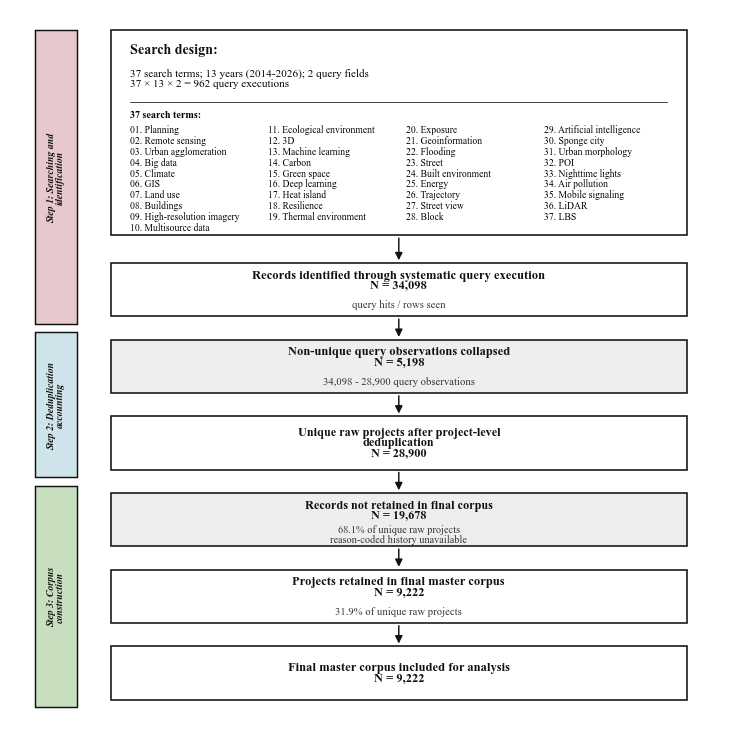

In [5]:
# Draw Fig. 2: a single-column, equal-width systematic-review data-accounting flowchart.
PALETTE = {
    "ink": "#111111",
    "muted": "#333333",
    "line": "#111111",
    "box_fill": "#FFFFFF",
    "accounting_fill": "#EEEEEE",
    "stage_search_fill": "#E8C8CF",
    "stage_dedup_fill": "#CFE3EA",
    "stage_corpus_fill": "#C8DFBF",
}

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": TEXT_FONT_FAMILIES,
    "font.size": 10,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

layout_boxes = {}
layout_box_patches = {}
layout_text_artists = []
arrow_segments = []
node_fill_by_key = {}
search_term_column_artists = []

SEARCH_TERM_COL_COUNT = 4
SEARCH_TERM_LINESPACING = 1.10
SEARCH_TERM_FONT_SIZE = 6.95
SEARCH_TERM_LABEL_FONT_SIZE = 7.25
SEARCH_DESIGN_TITLE_FONT_SIZE = 10.2
SEARCH_DESIGN_DETAIL_COLOR = "#000000"
MIN_ARROW_GAP = 0.030


def draw_rect(ax, x, y, w, h, fill="white", edge=None, lw=1.15, alpha=1.0, key=None):
    patch = Rectangle((x, y), w, h, facecolor=fill, edgecolor=edge or PALETTE["ink"], linewidth=lw, alpha=alpha)
    ax.add_patch(patch)
    if key is not None:
        layout_boxes[key] = (x, y, w, h)
        layout_box_patches[key] = patch
        node_fill_by_key[key] = fill
    return patch


def register_text(box_key, artist):
    layout_text_artists.append((box_key, artist))
    return artist


def draw_arrow(ax, start, end, lw=1.05, mutation_scale=11, color=None):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        linewidth=lw,
        color=color or PALETTE["line"],
        shrinkA=2,
        shrinkB=2,
    )
    ax.add_patch(arrow)
    return arrow


def add_center_text(ax, box_key, x, y, w, h, title, subtitle=None, title_size=9.0, subtitle_size=7.7, title_weight="bold"):
    if subtitle is None:
        title_artist = ax.text(
            x + w / 2,
            y + h / 2,
            title,
            ha="center",
            va="center",
            fontsize=title_size,
            color=PALETTE["ink"],
            fontfamily=TEXT_FONT_FAMILIES,
            fontweight=title_weight,
            linespacing=0.94,
        )
        register_text(box_key, title_artist)
        return

    title_artist = ax.text(
        x + w / 2,
        y + h * 0.675,
        title,
        ha="center",
        va="center",
        fontsize=title_size,
        color=PALETTE["ink"],
        fontfamily=TEXT_FONT_FAMILIES,
        fontweight=title_weight,
        linespacing=0.94,
    )
    subtitle_artist = ax.text(
        x + w / 2,
        y + h * 0.230,
        subtitle,
        ha="center",
        va="center",
        fontsize=subtitle_size,
        color=PALETTE["muted"],
        fontfamily=TEXT_FONT_FAMILIES,
        linespacing=0.95,
    )
    register_text(box_key, title_artist)
    register_text(box_key, subtitle_artist)


def draw_flow_box(ax, key, x, y, w, h, title, subtitle=None, fill=None, lw=1.15, title_size=9.0, subtitle_size=7.7):
    draw_rect(ax, x, y, w, h, fill=fill or PALETTE["box_fill"], edge=PALETTE["ink"], lw=lw, key=key)
    add_center_text(ax, key, x, y, w, h, title, subtitle, title_size=title_size, subtitle_size=subtitle_size)


def draw_search_box(ax, key, x, y, w, h, terms):
    draw_rect(ax, x, y, w, h, fill=PALETTE["box_fill"], edge=PALETTE["ink"], lw=1.15, key=key)
    title_artist = ax.text(
        x + 0.027,
        y + h - 0.017,
        "Search design:",
        ha="left",
        va="top",
        fontsize=SEARCH_DESIGN_TITLE_FONT_SIZE,
        fontfamily=TEXT_FONT_FAMILIES,
        fontweight="bold",
        color=PALETTE["ink"],
    )
    register_text(key, title_artist)

    summary_text = (
        "37 search terms; 13 years (2014-2026); 2 query fields\n"
        "37 × 13 × 2 = 962 query executions"
    )
    summary_artist = ax.text(
        x + 0.027,
        y + h - 0.052,
        summary_text,
        ha="left",
        va="top",
        fontsize=8.05,
        fontfamily=TEXT_FONT_FAMILIES,
        color=SEARCH_DESIGN_DETAIL_COLOR,
        linespacing=0.94,
    )
    register_text(key, summary_artist)

    rule_y = y + h - 0.099
    ax.plot([x + 0.027, x + w - 0.027], [rule_y, rule_y], color=PALETTE["line"], linewidth=0.55)

    search_terms_label_artist = ax.text(
        x + 0.027,
        rule_y - 0.011,
        "37 search terms:",
        ha="left",
        va="top",
        fontsize=SEARCH_TERM_LABEL_FONT_SIZE,
        fontfamily=TEXT_FONT_FAMILIES,
        fontweight="bold",
        color=SEARCH_DESIGN_DETAIL_COLOR,
    )
    register_text(key, search_terms_label_artist)

    col_count = SEARCH_TERM_COL_COUNT
    base_rows, extra_rows = divmod(len(terms), col_count)
    col_lengths = [base_rows + (1 if col_idx < extra_rows else 0) for col_idx in range(col_count)]
    col_gap = 0.020
    col_w = (w - 0.054 - col_gap * (col_count - 1)) / col_count
    term_top_y = rule_y - 0.030
    start_idx = 0
    for col_idx in range(col_count):
        column_terms = terms[start_idx:start_idx + col_lengths[col_idx]]
        column_text = "\n".join(f"{start_idx + offset + 1:02d}. {term}" for offset, term in enumerate(column_terms))
        term_artist = ax.text(
            x + 0.027 + col_idx * (col_w + col_gap),
            term_top_y,
            column_text,
            ha="left",
            va="top",
            fontsize=SEARCH_TERM_FONT_SIZE,
            fontfamily=TEXT_FONT_FAMILIES,
            color=SEARCH_DESIGN_DETAIL_COLOR,
            linespacing=SEARCH_TERM_LINESPACING,
        )
        search_term_column_artists.append((col_idx, column_terms, term_artist))
        register_text(key, term_artist)
        start_idx += len(column_terms)


def draw_stage_bar(ax, key, x, y, w, h, label, fill):
    draw_rect(ax, x, y, w, h, fill=fill, edge=PALETTE["ink"], lw=1.05, key=key)
    label_artist = ax.text(
        x + w / 2,
        y + h / 2,
        label,
        ha="center",
        va="center",
        fontsize=7.1,
        fontfamily=TEXT_FONT_FAMILIES,
        fontstyle="italic",
        fontweight="bold",
        rotation=90,
        rotation_mode="anchor",
        color=PALETTE["ink"],
        linespacing=0.96,
    )
    register_text(key, label_artist)


def draw_vertical_arrow_between(ax, upper_key, lower_key):
    ux, uy, uw, uh = layout_boxes[upper_key]
    lx, ly, lw, lh = layout_boxes[lower_key]
    start = (ux + uw / 2, uy)
    end = (lx + lw / 2, ly + lh)
    arrow_segments.append((upper_key, lower_key, start, end))
    return draw_arrow(ax, start, end)


def assert_registered_text_within_boxes(fig, inset_px=2.0):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for box_key, artist in layout_text_artists:
        text_bbox = artist.get_window_extent(renderer=renderer)
        box_bbox = layout_box_patches[box_key].get_window_extent(renderer=renderer)
        assert text_bbox.x0 >= box_bbox.x0 + inset_px, f"Text left overflow in {box_key}: {artist.get_text()}"
        assert text_bbox.x1 <= box_bbox.x1 - inset_px, f"Text right overflow in {box_key}: {artist.get_text()}"
        assert text_bbox.y0 >= box_bbox.y0 + inset_px, f"Text bottom overflow in {box_key}: {artist.get_text()}"
        assert text_bbox.y1 <= box_bbox.y1 - inset_px, f"Text top overflow in {box_key}: {artist.get_text()}"


fig = plt.figure(figsize=(7.20, 7.30))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

stage_x, stage_w = 0.035, 0.058
box_x, box_w = 0.140, 0.800
search_y, search_h = 0.690, 0.281
node_h, node_gap, first_node_top = 0.073, 0.032, 0.652

search_key = "search_design"
lower_box_keys = [
    "records_identified",
    "nonunique_collapsed",
    "unique_raw",
    "not_retained",
    "projects_retained",
    "final_master",
]

node_tops = {key: first_node_top - idx * (node_h + node_gap) for idx, key in enumerate(lower_box_keys)}
node_bottoms = {key: node_tops[key] - node_h for key in lower_box_keys}
stage_pad = 0.010
stage_specs = [
    {
        "key": "stage_searching",
        "label": "Step 1: Searching and\nidentification",
        "fill": PALETTE["stage_search_fill"],
        "y": node_bottoms["records_identified"] - stage_pad,
        "h": (search_y + search_h) - (node_bottoms["records_identified"] - stage_pad),
    },
    {
        "key": "stage_deduplication",
        "label": "Step 2: Deduplication\naccounting",
        "fill": PALETTE["stage_dedup_fill"],
        "y": node_bottoms["unique_raw"] - stage_pad,
        "h": (node_tops["nonunique_collapsed"] + stage_pad) - (node_bottoms["unique_raw"] - stage_pad),
    },
    {
        "key": "stage_corpus",
        "label": "Step 3: Corpus\nconstruction",
        "fill": PALETTE["stage_corpus_fill"],
        "y": node_bottoms["final_master"] - stage_pad,
        "h": (node_tops["not_retained"] + stage_pad) - (node_bottoms["final_master"] - stage_pad),
    },
]
stage_bar_keys = [spec["key"] for spec in stage_specs]
for spec in stage_specs:
    draw_stage_bar(ax, spec["key"], stage_x, spec["y"], stage_w, spec["h"], spec["label"], spec["fill"])

draw_search_box(ax, search_key, box_x, search_y, box_w, search_h, search_terms_english)

node_specs = [
    {
        "key": "records_identified",
        "title": f"Records identified through systematic query execution\nN = {query_rows_seen_n:,}",
        "subtitle": "query hits / rows seen",
        "fill": PALETTE["box_fill"],
        "lw": 1.15,
        "title_size": 9.0,
        "subtitle_size": 7.7,
    },
    {
        "key": "nonunique_collapsed",
        "title": f"Non-unique query observations collapsed\nN = {collapsed_query_observations_n:,}",
        "subtitle": f"{query_rows_seen_n:,} - {raw_unique_after_merge_n:,} query observations",
        "fill": PALETTE["accounting_fill"],
        "lw": 1.15,
        "title_size": 9.0,
        "subtitle_size": 7.7,
    },
    {
        "key": "unique_raw",
        "title": f"Unique raw projects after project-level\ndeduplication\nN = {raw_unique_after_merge_n:,}",
        "subtitle": None,
        "fill": PALETTE["box_fill"],
        "lw": 1.15,
        "title_size": 8.8,
        "subtitle_size": 7.7,
    },
    {
        "key": "not_retained",
        "title": f"Records not retained in final corpus\nN = {not_carried_forward_n:,}",
        "subtitle": f"{not_retained_pct:.1%} of unique raw projects\nreason-coded history unavailable",
        "fill": PALETTE["accounting_fill"],
        "lw": 1.15,
        "title_size": 8.8,
        "subtitle_size": 7.4,
    },
    {
        "key": "projects_retained",
        "title": f"Projects retained in final master corpus\nN = {final_corpus_n:,}",
        "subtitle": f"{final_retention_pct:.1%} of unique raw projects",
        "fill": PALETTE["box_fill"],
        "lw": 1.15,
        "title_size": 9.0,
        "subtitle_size": 7.7,
    },
    {
        "key": "final_master",
        "title": f"Final master corpus included for analysis\nN = {final_corpus_n:,}",
        "subtitle": None,
        "fill": PALETTE["box_fill"],
        "lw": 1.15,
        "title_size": 9.0,
        "subtitle_size": 7.7,
    },
]

for idx, spec in enumerate(node_specs):
    top_y = node_tops[spec["key"]]
    y = node_bottoms[spec["key"]]
    draw_flow_box(
        ax,
        spec["key"],
        box_x,
        y,
        box_w,
        node_h,
        spec["title"],
        spec["subtitle"],
        fill=spec["fill"],
        lw=spec["lw"],
        title_size=spec["title_size"],
        subtitle_size=spec["subtitle_size"],
    )

arrow_chain = [search_key] + lower_box_keys
for upper_key, lower_key in zip(arrow_chain[:-1], arrow_chain[1:]):
    draw_vertical_arrow_between(ax, upper_key, lower_key)

assert len(search_terms) == 37 and len(search_terms_english) == 37
assert_registered_text_within_boxes(fig)

if EXPORT_FIG2_OUTPUTS:
    import re

    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    for ext in ["svg", "pdf", "png", "tiff"]:
        out_path = FIGURE_BASE.with_suffix(f".{ext}")
        save_kwargs = {"facecolor": "white", "bbox_inches": "tight", "pad_inches": 0.030}
        if ext in {"png", "tiff"}:
            save_kwargs["dpi"] = 600
        if ext == "tiff":
            save_kwargs["pil_kwargs"] = {"compression": "tiff_lzw"}
        fig.savefig(out_path, **save_kwargs)

    svg_path = FIGURE_BASE.with_suffix(".svg")
    svg_text = svg_path.read_text(encoding="utf-8")
    svg_text = re.sub(r"\n? <metadata>.*?</metadata>\n?", "\n", svg_text, count=1, flags=re.S)
    search_design_detail_texts = [
        "37 search terms; 13 years (2014-2026); 2 query fields",
        "37 × 13 × 2 = 962 query executions",
        "37 search terms:",
        *[f"{idx:02d}. {term}" for idx, term in enumerate(search_terms_english, start=1)],
    ]
    for detail_text in search_design_detail_texts:
        svg_text = re.sub(
            rf'(<text style=")(?![^"]*fill: )([^"]*"[^>]*>{re.escape(detail_text)}</text>)',
            r'\1fill: #000000; \2',
            svg_text,
            count=1,
        )
    svg_path.write_text(svg_text, encoding="utf-8")

plt.show()


In [6]:
# Generate the in-notebook method summary; by default, do not write it to output/logs.
figure_status_lines = []
for ext in ["svg", "pdf", "png", "tiff"]:
    path = FIGURE_BASE.with_suffix(f".{ext}")
    status = "success" if path.exists() and path.stat().st_size > 0 else "failed"
    size_kb = path.stat().st_size / 1024 if path.exists() else 0
    figure_status_lines.append(f"- `{path.relative_to(PROJECT_ROOT)}`: {status}, {size_kb:.1f} KB")

workflow_text = "\n".join(f"- {note}" for note in workflow_notes)
method_summary_text = f"""# 02 Screening Workflow and Sample Construction Method Summary

Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Fig. 2 Layout

{workflow_text}

## Current Sample Construction Chain

1. Search design: {query_keyword_n} search terms; {query_year_n} years: {query_year_min}-{query_year_max}; {query_field_n} query fields; {query_keyword_n} × {query_year_n} × {query_field_n} = {query_executions_n:,} query executions.
2. Records identified through systematic query execution: N={query_rows_seen_n:,}, from the sum of rows_seen in raw query progress and cross-checked against the raw query_count sum.
3. Non-unique query observations collapsed: N={collapsed_query_observations_n:,}, placed below Records identified and calculated as {query_rows_seen_n:,} - {raw_unique_after_merge_n:,}.
4. Unique raw projects after project-level deduplication: N={raw_unique_after_merge_n:,}, from the current unique projects in the raw collection.
5. Records not retained in final corpus: N={not_carried_forward_n:,}, placed below Unique raw and representing {not_retained_pct:.1%} of unique raw projects; reason-coded history unavailable.
6. Projects retained in final master corpus: N={final_corpus_n:,}, representing {final_retention_pct:.1%} of unique raw projects.
7. Final master corpus included for analysis: N={final_corpus_n:,}.

## Figure Export Status

{chr(10).join(figure_status_lines)}
"""

if EXPORT_TABLE_AND_LOG_OUTPUTS:
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    METHOD_LOG_PATH.write_text(method_summary_text, encoding="utf-8")

print(method_summary_text)


# 02 Screening Workflow and Sample Construction Method Summary

Generated at: 2026-06-23 23:21:26

## Fig. 2 Layout

- Fig2 is a single-column systematic review data-accounting flowchart.
- The Search design header and all six downstream boxes share the same left/right boundaries and width.
- Three left-side stage bars label searching, deduplication accounting, and corpus construction.
- Non-unique query observations are placed immediately below records identified.
- Records not retained in final corpus are placed immediately below unique raw projects.
- Reason-coded exclusion history was unavailable; counts describe data accounting, not audited screening reasons.

## Current Sample Construction Chain

1. Search design: 37 search terms; 13 years: 2014-2026; 2 query fields; 37 × 13 × 2 = 962 query executions.
2. Records identified through systematic query execution: N=34,098, from the sum of rows_seen in raw query progress and cross-checked against the raw query_count sum.
3. Non-unique

In [7]:
# Final quick checks: validate in-memory accounting, single-column layout, and exported Fig. 2 files without checking or overwriting other output files.
assert KEYWORD_TERMS_PATH.exists(), f"Keyword file does not exist: {KEYWORD_TERMS_PATH}"
assert RAW_COLLECTION_PATH.exists(), f"raw collection does not exist: {RAW_COLLECTION_PATH}"
assert RAW_QUERY_LIST_PATH.exists(), f"raw query list does not exist: {RAW_QUERY_LIST_PATH}"
assert RAW_QUERY_PROGRESS_PATH.exists(), f"raw query progress does not exist: {RAW_QUERY_PROGRESS_PATH}"
assert MASTER_PATH.exists(), f"final master data does not exist: {MASTER_PATH}"

assert workflow_mode == "single_column_systematic_review_flowchart"
assert len(search_terms) == 37
assert len(search_terms_english) == 37 and len(set(search_terms_english)) == 37
assert search_terms_english == [FIG6_KEYWORD_EN_LABELS[term] for term in search_terms]
assert search_terms == search_terms_from_keyword_file == search_terms_from_query_list == search_terms_from_progress
assert query_executions_n == 962
assert query_keyword_n == 37 and query_year_n == 13 and query_field_n == 2
assert query_year_min == 2014 and query_year_max == 2026
assert query_rows_seen_n == raw_query_count_sum_n == 34098
assert raw_unique_after_merge_n == raw_retrieved_n == 28900
assert collapsed_query_observations_n == 5198
assert final_corpus_n == len(master_df) == 9222
assert final_traced_to_raw_n == 9222
assert final_only_n == 0
assert not_carried_forward_n == 19678
assert not_carried_by_key_n == 19678
assert round(final_retention_pct * 100, 1) == 31.9
assert round(not_retained_pct * 100, 1) == 68.1
assert not reason_coded_exclusion_history_available

expected_flow_nodes = [
    "Search design",
    "Records identified through systematic query execution",
    "Non-unique query observations collapsed",
    "Unique raw projects after project-level deduplication",
    "Records not retained in final corpus",
    "Projects retained in final master corpus",
    "Final master corpus included for analysis",
]
expected_flow_n = [962, 34098, 5198, 28900, 19678, 9222, 9222]
assert flow_df["flow_node"].tolist() == expected_flow_nodes
assert flow_df["n"].tolist() == expected_flow_n
assert flow_df["figure_role"].tolist() == ["search_header"] + ["flow_box"] * 6

assert len(lower_box_keys) == 6
assert lower_box_keys == [
    "records_identified",
    "nonunique_collapsed",
    "unique_raw",
    "not_retained",
    "projects_retained",
    "final_master",
]
search_x, search_y_check, search_w, search_h_check = layout_boxes["search_design"]
assert abs(search_h_check - search_h) < 1e-12
assert search_h < 0.312, "Search design height was not reduced from the prior layout"
assert abs(node_h - 0.073) < 1e-12
assert node_gap > 0.018, "Flow-box spacing was not increased from the prior layout"
assert len(search_term_column_artists) == SEARCH_TERM_COL_COUNT == 4
search_column_lengths = [len(column_terms) for _, column_terms, _ in search_term_column_artists]
assert search_column_lengths == [10, 9, 9, 9], f"Unexpected search-term column split: {search_column_lengths}"
assert sum(search_column_lengths) == 37
assert SEARCH_TERM_LINESPACING > 0.98, "Search-term vertical spacing was not increased"
for key in lower_box_keys:
    x, y, w, h = layout_boxes[key]
    assert abs(x - search_x) < 1e-12, f"{key} left boundary differs from Search design"
    assert abs(w - search_w) < 1e-12, f"{key} width differs from Search design"
    assert abs((x + w) - (search_x + search_w)) < 1e-12, f"{key} right boundary differs from Search design"
    assert abs(h - node_h) < 1e-12, f"{key} height differs from configured node height"

for upper_key, lower_key in zip((["search_design"] + lower_box_keys)[:-1], (["search_design"] + lower_box_keys)[1:]):
    upper_y = layout_boxes[upper_key][1]
    lower_top = layout_boxes[lower_key][1] + layout_boxes[lower_key][3]
    assert upper_y > lower_top, f"{lower_key} is not below {upper_key}"

assert stage_bar_keys == ["stage_searching", "stage_deduplication", "stage_corpus"]
for key in stage_bar_keys:
    sx, sy, sw, sh = layout_boxes[key]
    assert sx + sw < search_x, f"{key} is not left of the main flow"
    assert sh > 0, f"{key} has invalid height"

special_accounting_keys = {"nonunique_collapsed", "not_retained"}
ordinary_main_keys = {"search_design", *lower_box_keys} - special_accounting_keys
for key in special_accounting_keys:
    assert node_fill_by_key[key].lower() == PALETTE["accounting_fill"].lower(), f"{key} is not grey accounting fill"
for key in ordinary_main_keys:
    assert node_fill_by_key[key].lower() == PALETTE["box_fill"].lower(), f"{key} is not white fill"

expected_arrow_pairs = list(zip((["search_design"] + lower_box_keys)[:-1], (["search_design"] + lower_box_keys)[1:]))
assert [(a[0], a[1]) for a in arrow_segments] == expected_arrow_pairs
for upper_key, lower_key, start, end in arrow_segments:
    assert abs(start[0] - end[0]) < 1e-12, f"Arrow from {upper_key} to {lower_key} is not vertical"
    assert start[1] > end[1], f"Arrow from {upper_key} to {lower_key} does not point downward"
    assert (start[1] - end[1]) >= MIN_ARROW_GAP, f"Arrow from {upper_key} to {lower_key} lacks visible shaft length"

assert_registered_text_within_boxes(fig)

if EXPORT_FIG2_OUTPUTS:
    import xml.etree.ElementTree as ET
    from PIL import Image

    svg_path = FIGURE_BASE.with_suffix(".svg")
    svg_text = svg_path.read_text(encoding="utf-8")
    visible_text = " ".join("".join(ET.fromstring(svg_text).itertext()).split())
    svg_text_lower = visible_text.lower()

    forbidden_text = [
        "web of science",
        "scopus",
        "criteria #",
        "criteria",
        "excluded after screening",
        "not written in english",
        "review papers",
        "language",
        "irrelevant",
        "quality",
        "title",
        "abstract",
        "full-text",
        "side_annotation",
        "unique raw projects screened for final corpus",
        "unique raw projects entering final corpus construction",
        "final corpus retained for analysis",
        "difference:",
        "no reason-coded audit trail",
    ]
    for term in forbidden_text:
        assert term not in svg_text_lower, f"Fig2 SVG visible text contains forbidden text: {term}"

    old_reference_numbers = ["N = 1910", "N=1910", "N = 1113", "N=1113", "N = 154", "N=154", "N = 170", "N=170"]
    for term in old_reference_numbers:
        assert term not in visible_text, f"Fig2 SVG visible text contains reference-image old number: {term}"

    removed_panel_labels = ["(a)", "(b)"]
    for term in removed_panel_labels:
        assert term not in visible_text, f"Fig2 SVG still contains removed panel label: {term}"

    required_text = [
        "Search design:",
        "Step 1: Searching and identification",
        "Step 2: Deduplication accounting",
        "Step 3: Corpus construction",
        "37 search terms:",
        "37 search terms",
        "13 years (2014-2026)",
        "2 query fields",
        "37 × 13 × 2 = 962 query executions",
        "Records identified through systematic query execution N = 34,098",
        "query hits / rows seen",
        "Non-unique query observations collapsed N = 5,198",
        "34,098 - 28,900 query observations",
        "Unique raw projects after project-level deduplication N = 28,900",
        "Records not retained in final corpus N = 19,678",
        "68.1% of unique raw projects",
        "reason-coded history unavailable",
        "Projects retained in final master corpus N = 9,222",
        "31.9% of unique raw projects",
        "Final master corpus included for analysis N = 9,222",
    ]
    for term in required_text:
        assert term in visible_text, f"Fig2 SVG missing required visible text: {term}"
    for idx, term in enumerate(search_terms_english, start=1):
        assert f"{idx:02d}. {term}" in visible_text, f"Fig2 SVG missing search term {idx}: {term}"
    for term in search_terms:
        if any("\u4e00" <= char <= "\u9fff" for char in term):
            assert term not in visible_text, f"Fig2 SVG still contains Chinese search term: {term}"
    assert visible_text.count("Search design") == 1
    assert visible_text.count("37 search terms") >= 2, "Fig2 SVG missing dedicated search-term label above the term list"
    assert "Times New Roman" in svg_text and "<text" in svg_text, "SVG text is not editable Times New Roman text"

    allowed_fig2_paths = {FIGURE_BASE.with_suffix(f".{ext}") for ext in ["svg", "pdf", "png", "tiff"]}
    fig2_related_paths = set(FIGURE_DIR.glob(f"{FIGURE_BASE.name}*"))
    assert fig2_related_paths == allowed_fig2_paths, f"Unexpected Fig2 process/backup files: {sorted(fig2_related_paths - allowed_fig2_paths)}"

    raster_info = {}
    for ext in ["png", "tiff"]:
        out_path = FIGURE_BASE.with_suffix(f".{ext}")
        with Image.open(out_path) as img:
            dpi = img.info.get("dpi", (0, 0))
            raster_info[ext] = {"size": img.size, "dpi": dpi}
            assert img.size[0] > 0 and img.size[1] > 0, f"Fig2 {ext} has invalid dimensions: {img.size}"
            assert abs(dpi[0] - 600) < 1 and abs(dpi[1] - 600) < 1, f"Fig2 {ext} dpi is not 600: {dpi}"

    for ext in ["svg", "pdf", "png", "tiff"]:
        out_path = FIGURE_BASE.with_suffix(f".{ext}")
        assert out_path.exists() and out_path.stat().st_size > 0, f"Fig. 2 export failed or is empty: {out_path}"

print("Notebook checks passed for single-column systematic-review Fig2 data-accounting flowchart.")
print(f"Search terms validated from {KEYWORD_TERMS_PATH.name}: {len(search_terms)}")
print(flow_df[["step_order", "figure_role", "workflow_stage", "flow_node", "n"]].to_string(index=False))
if EXPORT_FIG2_OUTPUTS:
    print(raster_info)


Notebook checks passed for single-column systematic-review Fig2 data-accounting flowchart.
Search terms validated from NSFC正式增量采集_37个关键词.csv: 37
 step_order   figure_role                     workflow_stage                                             flow_node     n
          1 search_header Single-column data-accounting flow                                         Search design   962
          2      flow_box Single-column data-accounting flow Records identified through systematic query execution 34098
          3      flow_box Single-column data-accounting flow               Non-unique query observations collapsed  5198
          4      flow_box Single-column data-accounting flow Unique raw projects after project-level deduplication 28900
          5      flow_box Single-column data-accounting flow                  Records not retained in final corpus 19678
          6      flow_box Single-column data-accounting flow              Projects retained in final master corpus  9222
        